In [18]:
import warnings
warnings.filterwarnings('ignore')
import sys
import os
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "..", "utils")))
from analysis_utils import (
    volcano_plot_br,
    plot_spatial_clusters_per_sample,
    plot_dotplot_by_treatment,
    plot_relative_cluster_composition,
    score_and_plot_modules, 
    volcano_plot_region_within_group
)
import scanpy as sc
import numpy as np

import scanpy as sc
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import pandas as pd
import scanpy as sc
from itertools import combinations
from scipy import sparse

In [7]:
ad = sc.read_h5ad('../data/ST_BRICHOS_region_subcluster.h5ad')

In [44]:
genes = ['Itm2b','Itm2c',"Cldn5", "Ocln", "F11r", "Tjp1"]

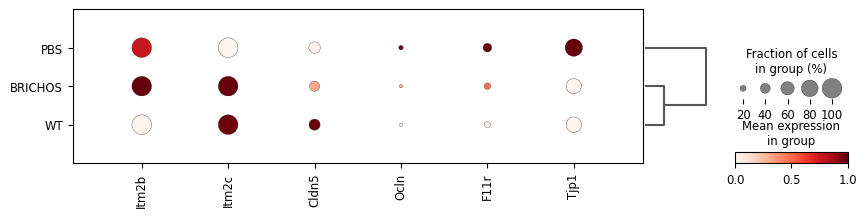

In [45]:
sc.pl.dotplot(
        ad,
        var_names=genes,
        groupby="treatment",
        standard_scale="var",
        color_map="Reds",
        dendrogram=True,
        figsize=(10, 2)
    )

In [58]:
# Run DE
sc.tl.rank_genes_groups(
    ad,
    groupby="treatment",        # column with your groups
    groups=["BRICHOS"],         # group of interest
    reference="WT",            # reference condition
    method="t-test",          # or "t-test_overestim_var", "logreg"
    layer=None,             # or None if using .X
    use_raw=False
)

# Get results as tidy DataFrame
de = sc.get.rank_genes_groups_df(ad, group="BRICHOS")
print(de[de.names.isin(genes)])

       names    scores  logfoldchanges         pvals  pvals_adj
630    Itm2b  4.684703        0.069292  2.871807e-06   0.000033
1528    F11r  2.836678        0.193994  4.574121e-03   0.021495
4514    Ocln  1.051574        0.115114  2.930389e-01   0.508493
7897   Itm2c  0.020109        0.000301  9.839571e-01   1.000000
8241    Tjp1 -0.012035       -0.000395  9.903978e-01   1.000000
17932  Cldn5 -5.141466       -0.254770  2.825795e-07   0.000004


In [59]:
# Run DE
sc.tl.rank_genes_groups(
    ad,
    groupby="treatment",        # column with your groups
    groups=["PBS"],         # group of interest
    reference="WT",            # reference condition
    method="t-test",          # or "t-test_overestim_var", "logreg"
    layer=None,             # or None if using .X
    use_raw=False
)

# Get results as tidy DataFrame
de = sc.get.rank_genes_groups_df(ad, group="PBS")
print(de[de.names.isin(genes)])

       names    scores  logfoldchanges         pvals     pvals_adj
1988    F11r  6.631334        0.384679  3.755176e-11  2.799734e-10
2115    Tjp1  6.434697        0.184314  1.388140e-10  9.789027e-10
4629   Itm2b  3.934238        0.052633  8.493434e-05  2.817272e-04
4706    Ocln  3.879648        0.355916  1.062045e-04  3.469410e-04
15811  Itm2c -1.148197       -0.015376  2.509570e-01  3.539353e-01
18403  Cldn5 -8.117707       -0.376921  6.383962e-16  7.614864e-15


In [60]:
# Run DE
sc.tl.rank_genes_groups(
    ad,
    groupby="treatment",        # column with your groups
    groups=["BRICHOS"],         # group of interest
    reference="PBS",            # reference condition
    method="t-test",          # or "t-test_overestim_var", "logreg"
    layer=None,             # or None if using .X
    use_raw=False
)

# Get results as tidy DataFrame
de = sc.get.rank_genes_groups_df(ad, group="BRICHOS")
print(de[de.names.isin(genes)])

       names    scores  logfoldchanges         pvals     pvals_adj
486    Cldn5  3.755785        0.122151  1.735490e-04  4.216946e-04
967    Itm2b  1.813798        0.016659  6.973166e-02  1.101178e-01
1071   Itm2c  1.614673        0.015677  1.064059e-01  1.594388e-01
11406   Ocln -3.692788       -0.240802  2.226320e-04  5.323351e-04
12877   F11r -4.664104       -0.190686  3.128845e-06  9.382533e-06
17431   Tjp1 -9.227090       -0.184709  3.200600e-20  4.167670e-19
